In [1]:
import pandas as pd

df = pd.read_csv("../data/customer_churn.csv")

print("Shape:", df.shape)
df.head()


Shape: (5000, 21)


,CustomerID,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,CUST100001,Female,0,Yes,No,61,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,No,Mailed check,36.33,2054.28,No
1,CUST100002,Male,0,No,Yes,33,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Mailed check,34.76,1179.14,No
2,CUST100003,Male,1,Yes,Yes,51,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Credit card,35.64,1766.36,No
3,CUST100004,Female,0,Yes,No,70,Yes,Yes,Fiber optic,Yes,...,No,No,No,Yes,Month-to-month,No,Electronic check,92.60,6493.43,No
4,CUST100005,Female,0,No,No,4,Yes,No,Fiber optic,Yes,...,No,No,No,Yes,One year,No,Electronic check,78.75,253.24,Yes


In [2]:
import numpy as np


import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   CustomerID        5000 non-null   str    
 1   Gender            5000 non-null   str    
 2   SeniorCitizen     5000 non-null   int64  
 3   Partner           5000 non-null   str    
 4   Dependents        5000 non-null   str    
 5   Tenure            5000 non-null   int64  
 6   PhoneService      5000 non-null   str    
 7   MultipleLines     5000 non-null   str    
 8   InternetService   5000 non-null   str    
 9   OnlineSecurity    5000 non-null   str    
 10  OnlineBackup      5000 non-null   str    
 11  DeviceProtection  5000 non-null   str    
 12  TechSupport       5000 non-null   str    
 13  StreamingTV       5000 non-null   str    
 14  StreamingMovies   5000 non-null   str    
 15  Contract          5000 non-null   str    
 16  PaperlessBilling  5000 non-null   str    
 17  Paymen

In [4]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,5000.0,0.151200,0.358280,0.0,0.0000,0.000,0.0000,1.00
Tenure,5000.0,36.212400,20.839303,1.0,18.0000,36.000,54.0000,72.00
MonthlyCharges,5000.0,65.024434,22.424917,18.0,49.7425,68.985,83.1425,112.81
TotalCharges,5000.0,2348.576574,1631.728808,18.0,1012.8500,2027.775,3497.6550,7298.05


In [5]:
df.describe(include="object").T

,count,unique,top,freq
CustomerID,5000,5000,CUST100001,1
Gender,5000,2,Female,2530
Partner,5000,2,Yes,2578
Dependents,5000,2,No,3508
PhoneService,5000,2,Yes,4463
MultipleLines,5000,3,No,2585
InternetService,5000,3,Fiber optic,2316
OnlineSecurity,5000,3,No,2721
OnlineBackup,5000,3,No,2533
DeviceProtection,5000,3,No,2491


## analysis

In [6]:
df["Churn"].value_counts()

Churn
No     4350
Yes     650
Name: count, dtype: int64

In [7]:
df["Churn"].value_counts(normalize=True) * 100

Churn
No     87.0
Yes    13.0
Name: proportion, dtype: float64

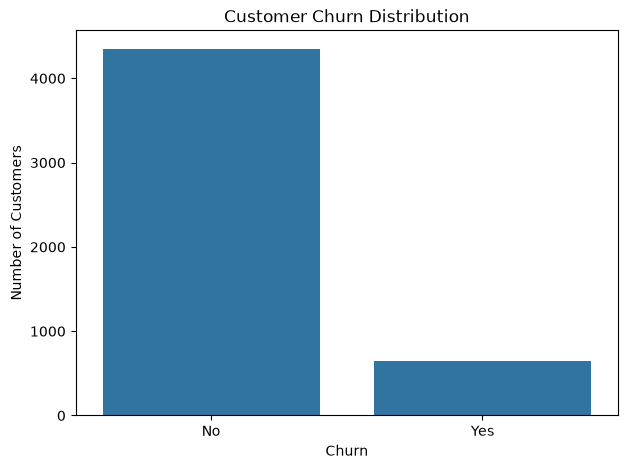

In [8]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="Churn"
)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

In [9]:
numeric_columns = df.select_dtypes(
    include=np.number
).columns

print(numeric_columns.tolist())

['SeniorCitizen', 'Tenure', 'MonthlyCharges', 'TotalCharges']


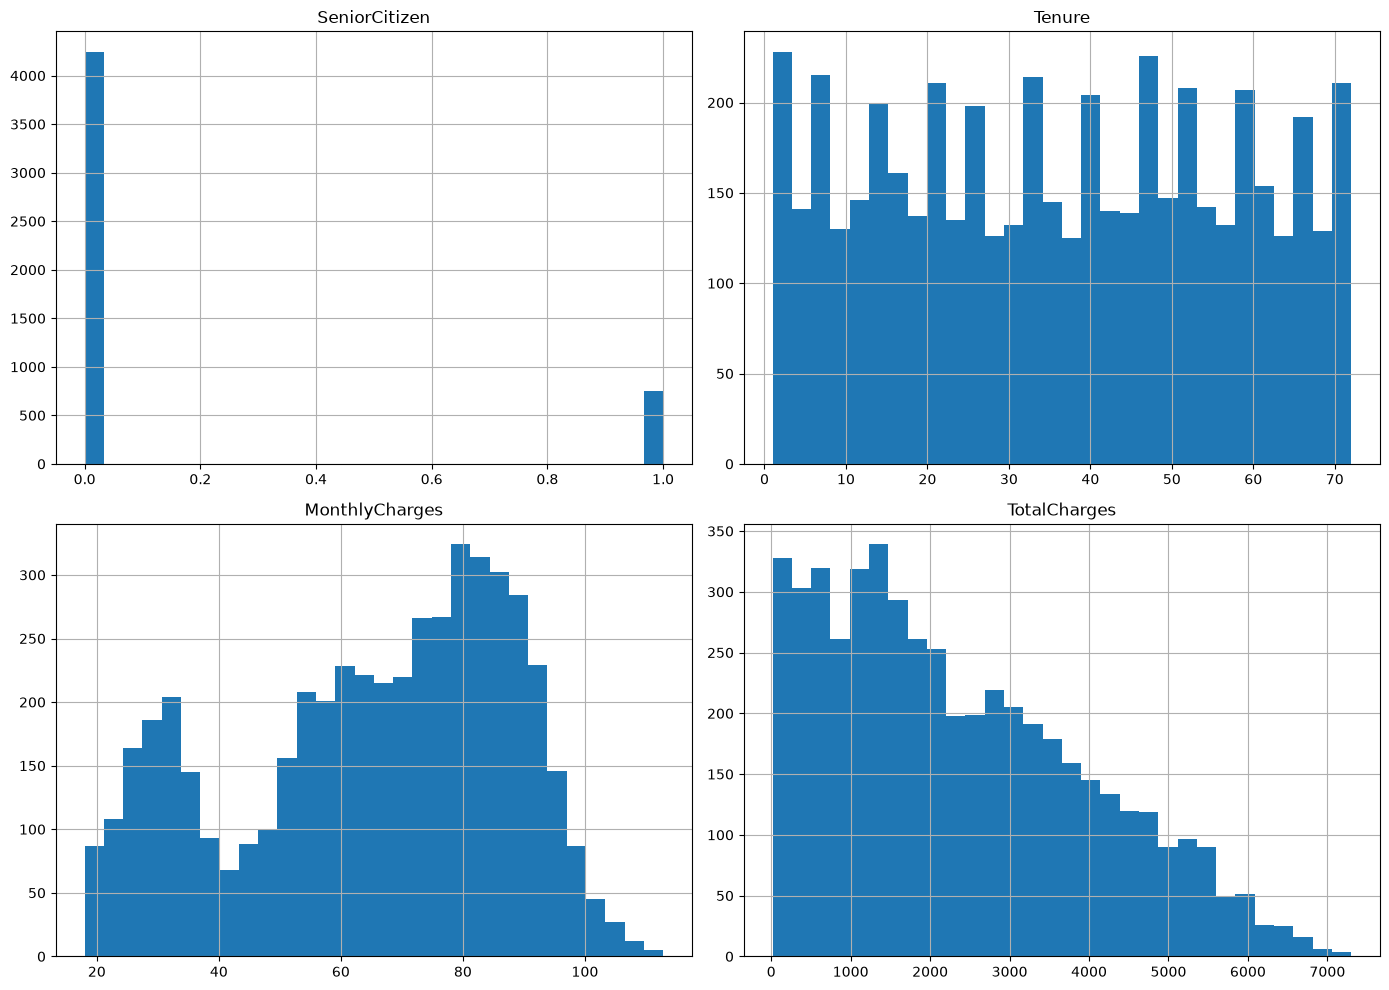

In [10]:
df[numeric_columns].hist(
    figsize=(14, 10),
    bins=30
)

plt.tight_layout()
plt.show()

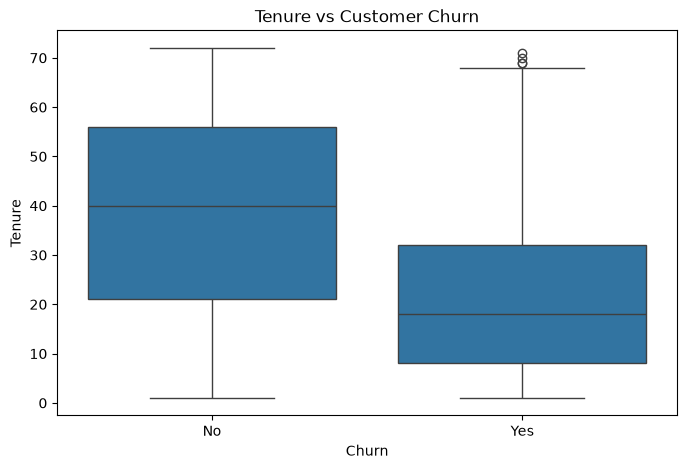

In [11]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Churn",
    y="Tenure"
)

plt.title("Tenure vs Customer Churn")
plt.show()

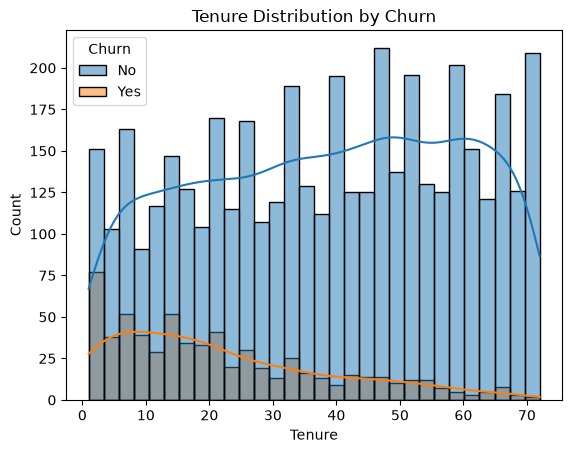

In [12]:
sns.histplot(
    data=df,
    x="Tenure",
    hue="Churn",
    bins=30,
    kde=True
)

plt.title("Tenure Distribution by Churn")
plt.show()

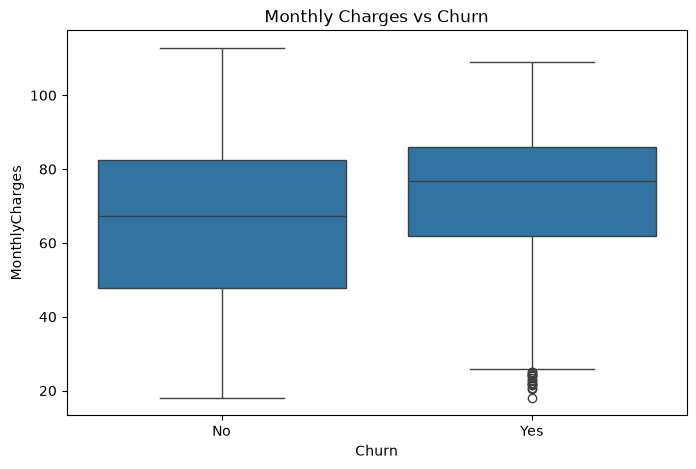

In [14]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Churn",
    y="MonthlyCharges"
)

plt.title("Monthly Charges vs Churn")
plt.show()

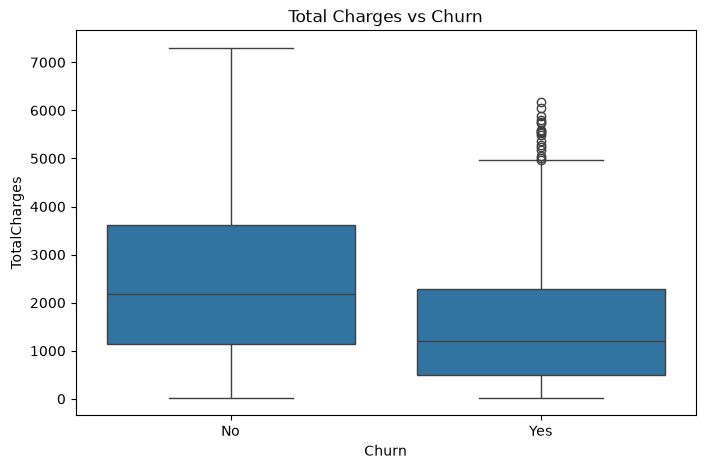

In [15]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Churn",
    y="TotalCharges"
)

plt.title("Total Charges vs Churn")
plt.show()

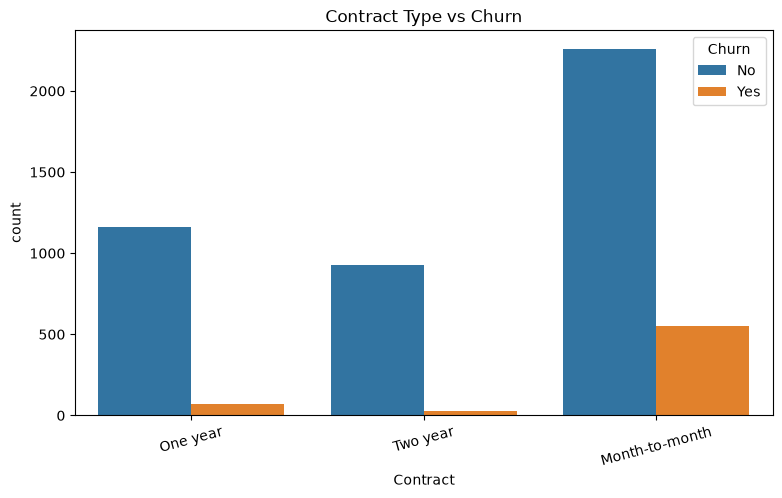

In [16]:
plt.figure(figsize=(9, 5))

sns.countplot(
    data=df,
    x="Contract",
    hue="Churn"
)

plt.title("Contract Type vs Churn")
plt.xticks(rotation=15)

plt.show()

In [17]:
contract_churn = pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
) * 100

print(contract_churn)

Churn                  No        Yes
Contract                            
Month-to-month  80.341273  19.658727
One year        94.241687   5.758313
Two year        97.274633   2.725367


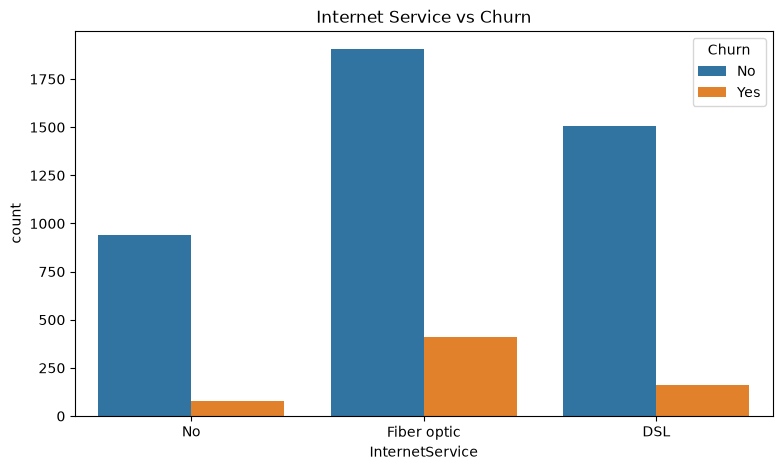

In [18]:
plt.figure(figsize=(9, 5))

sns.countplot(
    data=df,
    x="InternetService",
    hue="Churn"
)

plt.title("Internet Service vs Churn")

plt.show()

In [19]:
internet_churn = pd.crosstab(
    df["InternetService"],
    df["Churn"],
    normalize="index"
) * 100

print(internet_churn)

Churn                   No        Yes
InternetService                      
DSL              90.281944   9.718056
Fiber optic      82.210708  17.789292
No               92.527040   7.472960


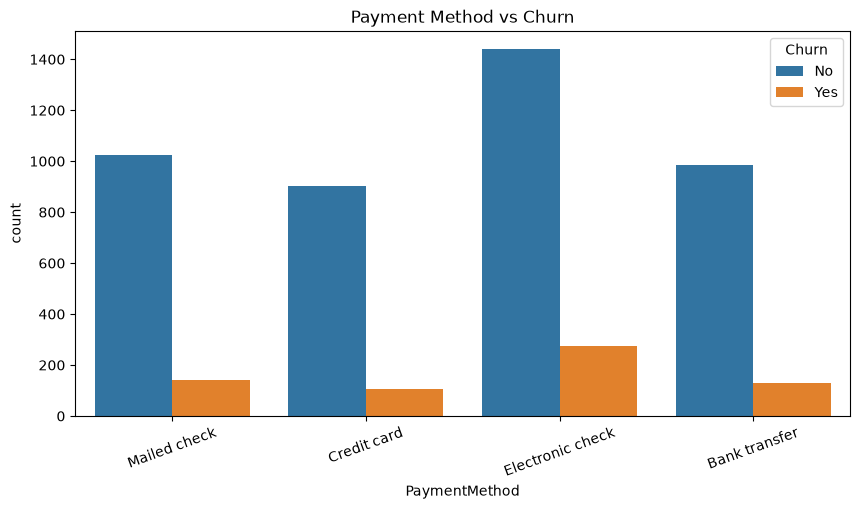

In [20]:
plt.figure(figsize=(10, 5))

sns.countplot(
    data=df,
    x="PaymentMethod",
    hue="Churn"
)

plt.title("Payment Method vs Churn")
plt.xticks(rotation=20)

plt.show()

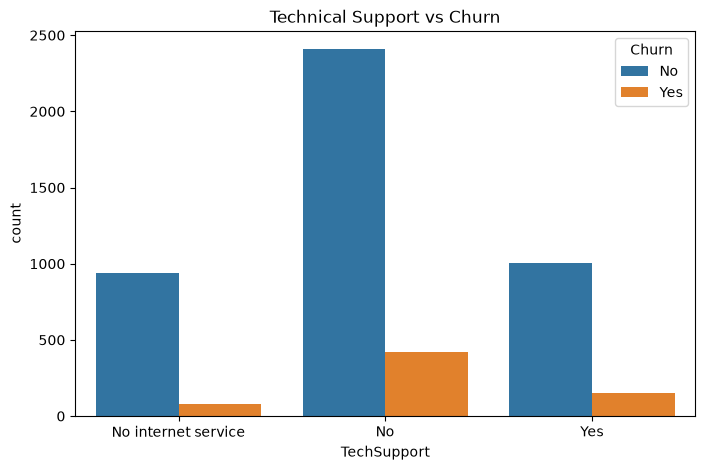

In [21]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="TechSupport",
    hue="Churn"
)

plt.title("Technical Support vs Churn")

plt.show()

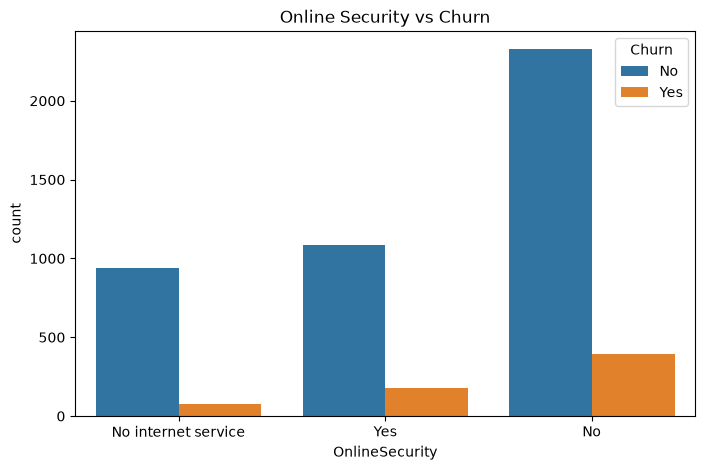

In [22]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="OnlineSecurity",
    hue="Churn"
)

plt.title("Online Security vs Churn")

plt.show()

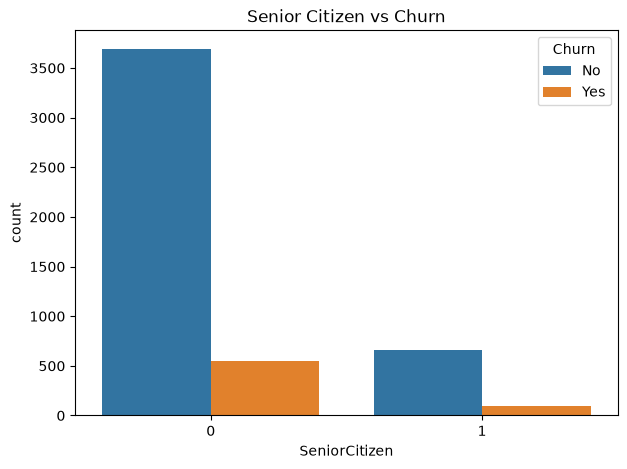

In [23]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="SeniorCitizen",
    hue="Churn"
)

plt.title("Senior Citizen vs Churn")

plt.show()

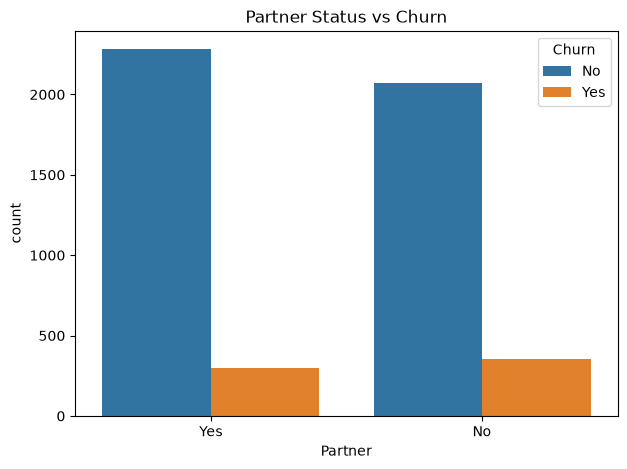

In [24]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="Partner",
    hue="Churn"
)

plt.title("Partner Status vs Churn")

plt.show()

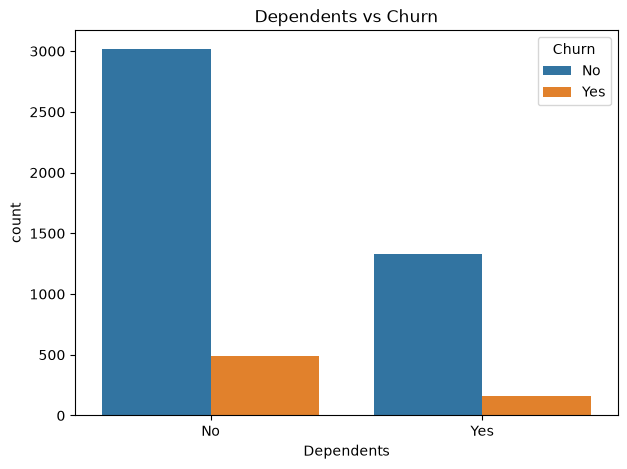

In [25]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="Dependents",
    hue="Churn"
)

plt.title("Dependents vs Churn")

plt.show()

In [26]:
df_corr = df.copy()

df_corr["Churn"] = df_corr["Churn"].map({
    "No": 0,
    "Yes": 1
})

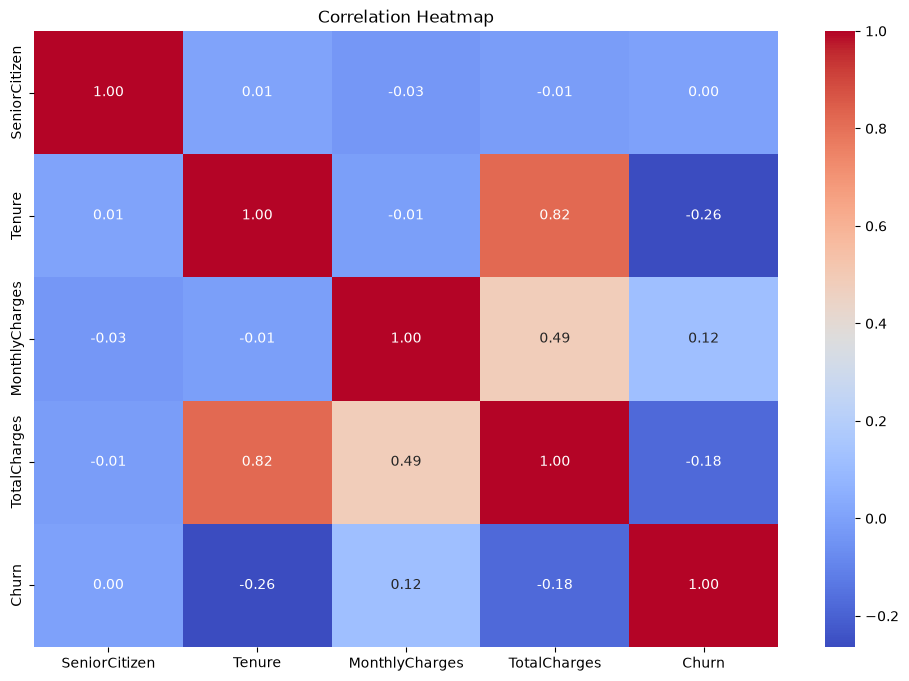

In [27]:
numeric_corr = df_corr.select_dtypes(
    include=np.number
)

plt.figure(figsize=(12, 8))

sns.heatmap(
    numeric_corr.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

## Data Cleaning

In [28]:
clean_df = df.copy()

In [29]:
print("Duplicates before cleaning:",
      clean_df.duplicated().sum())

Duplicates before cleaning: 0


In [30]:
print(
    clean_df.isnull().sum()
)

CustomerID          0
Gender              0
SeniorCitizen       0
Partner             0
Dependents          0
Tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [31]:
for column in clean_df.columns:
    print("\n", column)
    print(clean_df[column].unique()[:20])


 CustomerID
<ArrowStringArray>
['CUST100001', 'CUST100002', 'CUST100003', 'CUST100004', 'CUST100005',
 'CUST100006', 'CUST100007', 'CUST100008', 'CUST100009', 'CUST100010',
 'CUST100011', 'CUST100012', 'CUST100013', 'CUST100014', 'CUST100015',
 'CUST100016', 'CUST100017', 'CUST100018', 'CUST100019', 'CUST100020']
Length: 20, dtype: str

 Gender
<ArrowStringArray>
['Female', 'Male']
Length: 2, dtype: str

 SeniorCitizen
[0 1]

 Partner
<ArrowStringArray>
['Yes', 'No']
Length: 2, dtype: str

 Dependents
<ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str

 Tenure
[61 33 51 70  4  8 67 41 45 25 60 47 19  1 18 15 57 53  7 66]

 PhoneService
<ArrowStringArray>
['Yes', 'No']
Length: 2, dtype: str

 MultipleLines
<ArrowStringArray>
['Yes', 'No', 'No phone service']
Length: 3, dtype: str

 InternetService
<ArrowStringArray>
['No', 'Fiber optic', 'DSL']
Length: 3, dtype: str

 OnlineSecurity
<ArrowStringArray>
['No internet service', 'Yes', 'No']
Length: 3, dtype: str

 OnlineBackup
<ArrowS

In [32]:
clean_df = clean_df.drop(
    columns=["CustomerID"]
)

In [33]:
print(clean_df.columns)

Index(['Gender', 'SeniorCitizen', 'Partner', 'Dependents', 'Tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')


In [34]:
numeric_columns = clean_df.select_dtypes(
    include=np.number
).columns

print(numeric_columns.tolist())

['SeniorCitizen', 'Tenure', 'MonthlyCharges', 'TotalCharges']


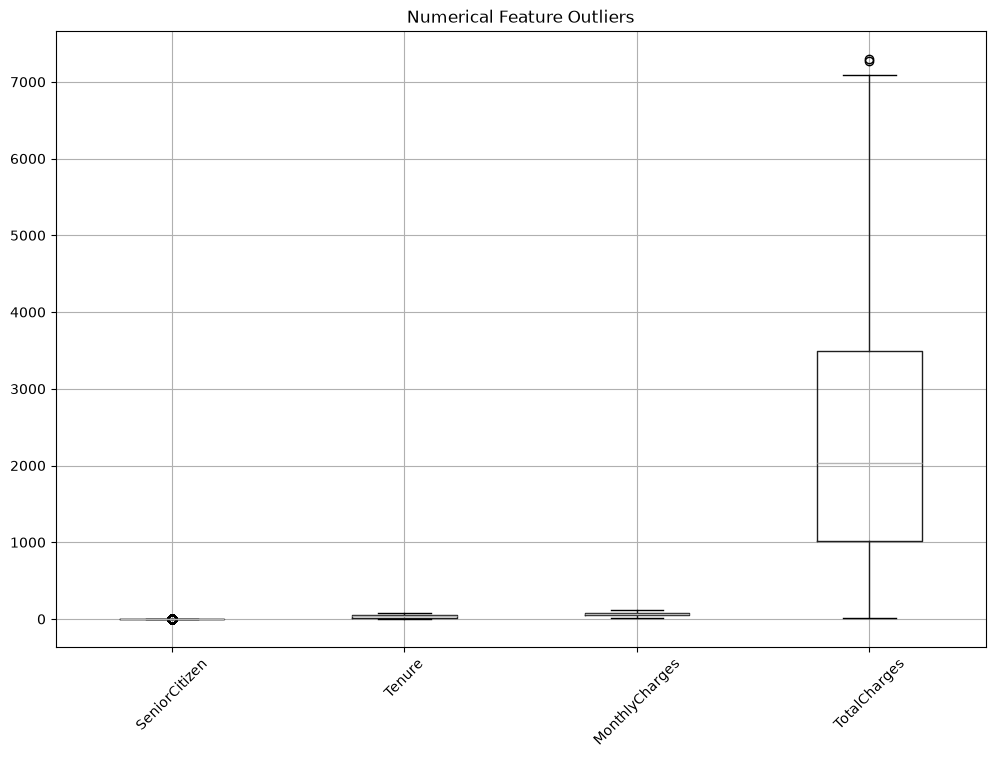

In [35]:
plt.figure(figsize=(12, 8))

clean_df[numeric_columns].boxplot()

plt.title("Numerical Feature Outliers")
plt.xticks(rotation=45)

plt.show()

In [36]:
categorical_columns = clean_df.select_dtypes(
    include="object"
).columns

for column in categorical_columns:
    print(
        f"\n{column}:",
        clean_df[column].unique()
    )


Gender: <ArrowStringArray>
['Female', 'Male']
Length: 2, dtype: str

Partner: <ArrowStringArray>
['Yes', 'No']
Length: 2, dtype: str

Dependents: <ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str

PhoneService: <ArrowStringArray>
['Yes', 'No']
Length: 2, dtype: str

MultipleLines: <ArrowStringArray>
['Yes', 'No', 'No phone service']
Length: 3, dtype: str

InternetService: <ArrowStringArray>
['No', 'Fiber optic', 'DSL']
Length: 3, dtype: str

OnlineSecurity: <ArrowStringArray>
['No internet service', 'Yes', 'No']
Length: 3, dtype: str

OnlineBackup: <ArrowStringArray>
['No internet service', 'Yes', 'No']
Length: 3, dtype: str

DeviceProtection: <ArrowStringArray>
['No internet service', 'No', 'Yes']
Length: 3, dtype: str

TechSupport: <ArrowStringArray>
['No internet service', 'No', 'Yes']
Length: 3, dtype: str

StreamingTV: <ArrowStringArray>
['No internet service', 'No', 'Yes']
Length: 3, dtype: str

StreamingMovies: <ArrowStringArray>
['No internet service', 'Yes', 'No']
Length

In [37]:
print(
    clean_df["Churn"].unique()
)

<ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str


In [38]:
clean_df["Churn"] = clean_df["Churn"].map({
    "No": 0,
    "Yes": 1
})

In [39]:
print(clean_df["Churn"].value_counts())

Churn
0    4350
1     650
Name: count, dtype: int64


In [40]:
print("Final Shape:", clean_df.shape)

print("\nMissing values:")
print(clean_df.isnull().sum())

print("\nDuplicates:",
      clean_df.duplicated().sum())

print("\nData types:")
print(clean_df.dtypes)

Final Shape: (5000, 20)

Missing values:
Gender              0
SeniorCitizen       0
Partner             0
Dependents          0
Tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Duplicates: 0

Data types:
Gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
Tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
Mo

In [41]:
clean_df.to_csv(
    "../data/customer_churn_cleaned.csv",
    index=False
)

 ## Feature Engineering

In [42]:
clean_df = pd.read_csv(
    "../data/customer_churn_cleaned.csv"
)

print(clean_df.shape)
clean_df.head()

(5000, 20)


,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,61,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,No,Mailed check,36.33,2054.28,0
1,Male,0,No,Yes,33,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Mailed check,34.76,1179.14,0
2,Male,1,Yes,Yes,51,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Credit card,35.64,1766.36,0
3,Female,0,Yes,No,70,Yes,Yes,Fiber optic,Yes,Yes,No,No,No,Yes,Month-to-month,No,Electronic check,92.60,6493.43,0
4,Female,0,No,No,4,Yes,No,Fiber optic,Yes,No,No,No,No,Yes,One year,No,Electronic check,78.75,253.24,1


In [43]:
clean_df["AverageMonthlySpend"] = (
    clean_df["TotalCharges"]
    / clean_df["Tenure"].replace(0, np.nan)
)

clean_df["AverageMonthlySpend"] = (
    clean_df["AverageMonthlySpend"]
    .fillna(clean_df["MonthlyCharges"])
)

In [44]:
clean_df["ChargeDifference"] = (
    clean_df["MonthlyCharges"]
    - clean_df["AverageMonthlySpend"]
)

In [45]:
service_columns = [
    "PhoneService",
    "MultipleLines",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies"
]

In [46]:
clean_df["ServiceCount"] = 0

for column in service_columns:
    clean_df["ServiceCount"] += (
        clean_df[column].isin(["Yes"])
    ).astype(int)

In [47]:
clean_df[
    ["ServiceCount"] + service_columns
].head()

,ServiceCount,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies
0,2,Yes,Yes,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service
1,2,Yes,Yes,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service
2,2,Yes,Yes,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service
3,5,Yes,Yes,Yes,Yes,No,No,No,Yes
4,3,Yes,No,Yes,No,No,No,No,Yes


In [48]:
clean_df["TenureGroup"] = pd.cut(
    clean_df["Tenure"],
    bins=[0, 12, 24, 48, 72],
    labels=[
        "New",
        "Developing",
        "Established",
        "Loyal"
    ]
)

In [49]:
print(
    clean_df["TenureGroup"].value_counts()
)

TenureGroup
Established    1649
Loyal          1648
New             860
Developing      843
Name: count, dtype: int64


In [50]:
clean_df["ChargeGroup"] = pd.cut(
    clean_df["MonthlyCharges"],
    bins=[0, 40, 70, 100, np.inf],
    labels=[
        "Low",
        "Medium",
        "High",
        "Very High"
    ]
)

In [51]:
clean_df["ContractRisk"] = (
    clean_df["Contract"]
    .map({
        "Month-to-month": 2,
        "One year": 1,
        "Two year": 0
    })
)

In [52]:
clean_df["ElectronicPayment"] = (
    clean_df["PaymentMethod"]
    == "Electronic check"
).astype(int)

In [53]:
clean_df["HasTechSupport"] = (
    clean_df["TechSupport"]
    == "Yes"
).astype(int)

In [54]:
clean_df["HasOnlineSecurity"] = (
    clean_df["OnlineSecurity"]
    == "Yes"
).astype(int)

In [55]:
new_features = [
    "AverageMonthlySpend",
    "ChargeDifference",
    "ServiceCount",
    "TenureGroup",
    "ChargeGroup",
    "ContractRisk",
    "ElectronicPayment",
    "HasTechSupport",
    "HasOnlineSecurity"
]

clean_df[new_features].head()

,AverageMonthlySpend,ChargeDifference,ServiceCount,TenureGroup,ChargeGroup,ContractRisk,ElectronicPayment,HasTechSupport,HasOnlineSecurity
0,33.676721,2.653279,2,Loyal,Low,1,0,0,0
1,35.731515,-0.971515,2,Established,Low,0,0,0,0
2,34.634510,1.005490,2,Loyal,Low,2,0,0,0
3,92.763286,-0.163286,5,Loyal,High,2,1,0,1
4,63.310000,15.440000,3,New,High,1,1,0,1


In [56]:
print(
    "Number of features:",
    clean_df.shape[1]
)

Number of features: 29


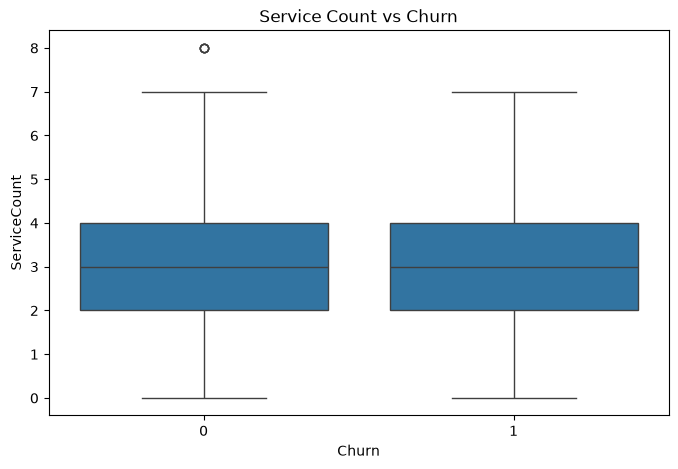

In [57]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=clean_df,
    x="Churn",
    y="ServiceCount"
)

plt.title("Service Count vs Churn")
plt.show()

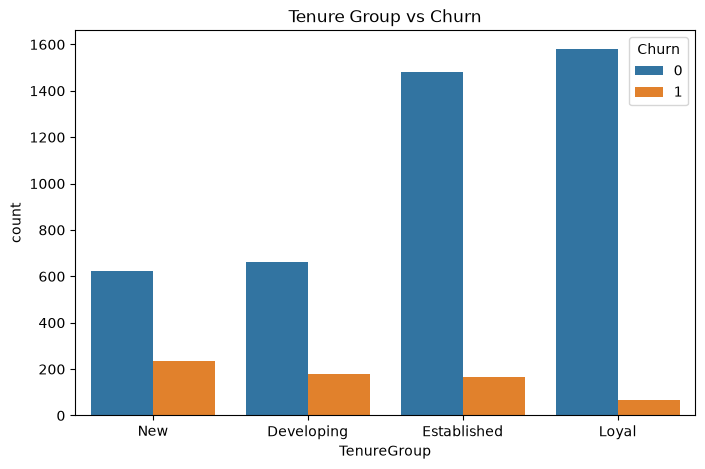

In [58]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=clean_df,
    x="TenureGroup",
    hue="Churn"
)

plt.title("Tenure Group vs Churn")
plt.show()

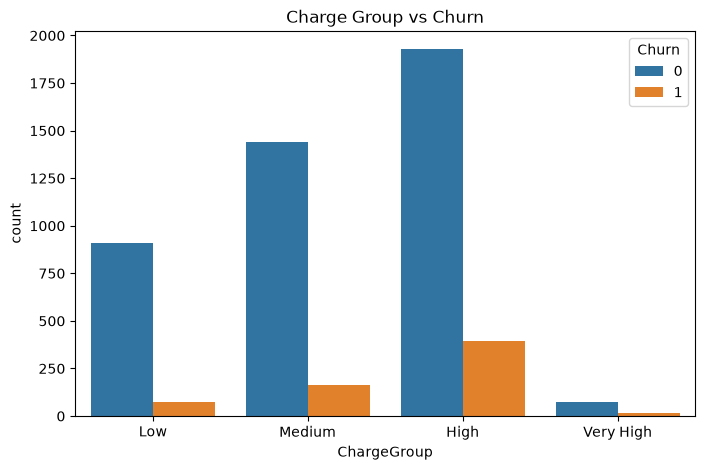

In [59]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=clean_df,
    x="ChargeGroup",
    hue="Churn"
)

plt.title("Charge Group vs Churn")
plt.show()